# This is my implementation of the tutorial for Tree Segmentation Using R and CHM's
based on this: https://tgoodbody.github.io/lidRtutorial/06_its.html

In [ ]:
# Environment Set-up 

# Clear environment
rm(list = ls(globalenv()))

# Load packages
library(lidR)
library(sf)
library(terra)

# Read in some color palettes
col <- height.colors(50)
# Force the color scale range to go from 0 to 5 meters
col1 <- pastel.colors(900)

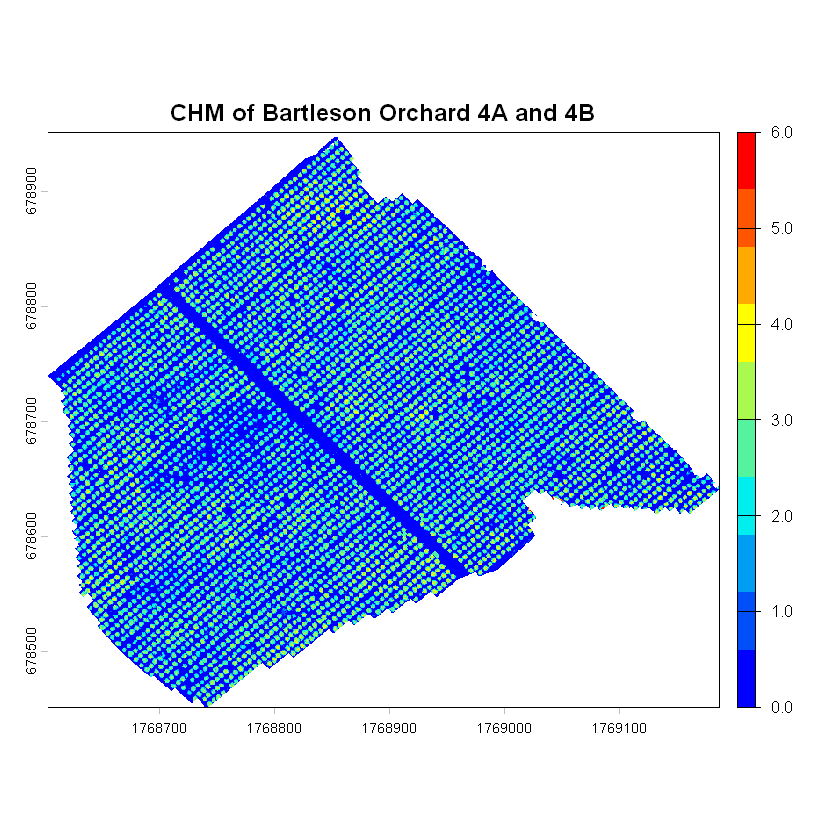

In [ ]:
#load CHM 
chm <- rast("C:\\Users\\davisk10\\OneDrive - Cal Poly\\Tree Biomass Estimation Research - Documents\\GitHub_Repository\\Rasters\\bart_chm_0.25m_clipped.tif")
plot(chm, range = c(0, 6), col = col, main = "CHM of Bartleson Orchard 4A and 4B")

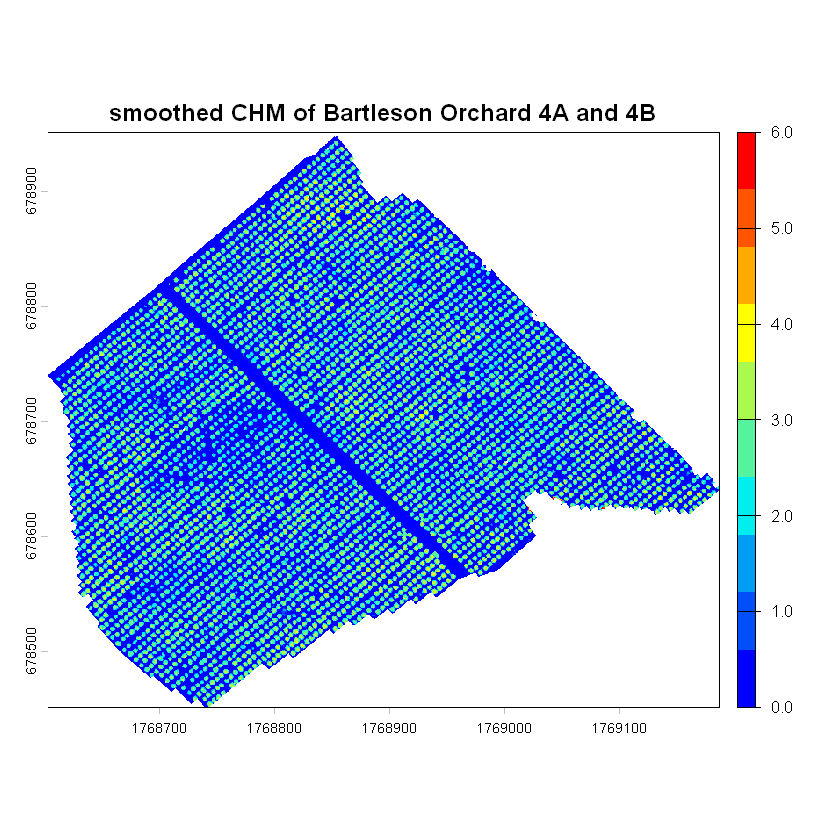

In [15]:
# optional smoothing
# Generate kernel and smooth chm
kernel <- matrix(1, 3, 3)
schm <- terra::focal(x = chm, w = kernel, fun = median, na.rm = TRUE)
plot(schm, range = c(0, 6), col = col, main = "smoothed CHM of Bartleson Orchard 4A and 4B")

,treeID,Z,geometry
,<int>,<dbl>,<POINT [m]>
1,1,3.126998,POINT Z (1768853 678942.6 3...
2,2,3.286996,POINT Z (1768849 678939.9 3...
3,3,3.007999,POINT Z (1768846 678936.9 3...
4,4,3.805001,POINT Z (1768859 678936.9 3...
5,5,3.591999,POINT Z (1768854 678934.4 3...
6,6,3.494000,POINT Z (1768863 678932.6 3...
7,7,3.430999,POINT Z (1768842 678932.1 3...
8,8,3.606999,POINT Z (1768851 678930.9 3...
9,9,3.695997,POINT Z (1768867 678929.6 3...


Warning message in plot.sf(ttops, col = "black", add = TRUE, cex = 0.1):
"ignoring all but the first attribute"


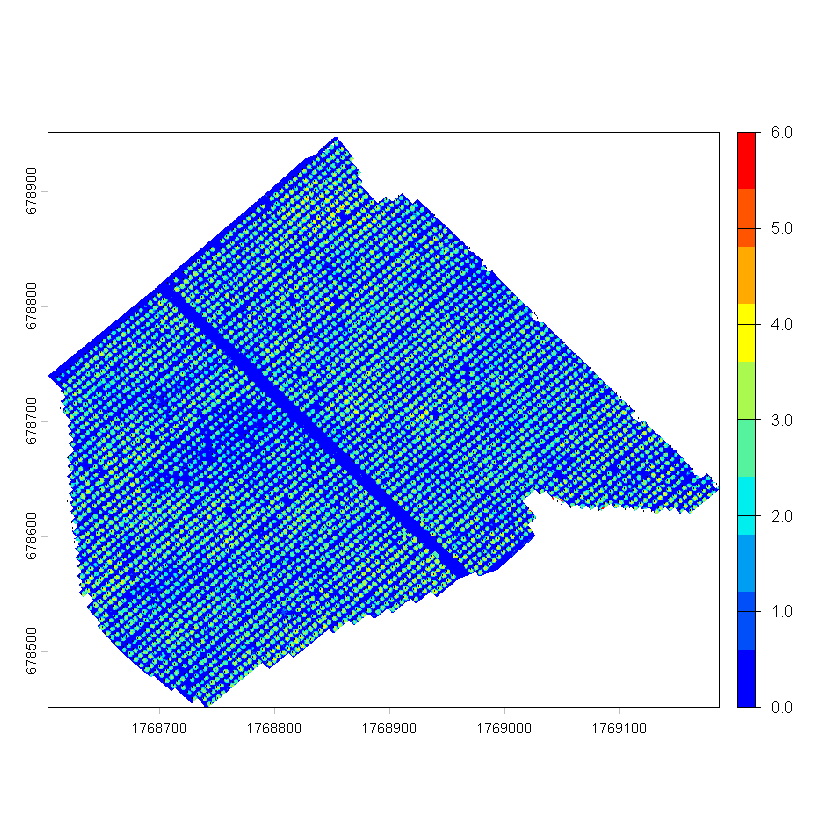

In [24]:
# Detect trees
ttops <- locate_trees(las = schm, algorithm = lmf(ws =5.5))
ttops

plot(chm, range = c(0, 6), col = col)
plot(ttops, col = "black", add = TRUE, cex = 0.1)

class       : SpatRaster
size        : 2000, 2336, 1  (nrow, ncol, nlyr)
resolution  : 0.25, 0.25  (x, y)
extent      : 1768604, 1769188, 678451.2, 678951.2  (xmin, xmax, ymin, ymax)
coord. ref. : NAD83(2011) / California zone 5 (EPSG:6423)
source(s)   : memory
varname     : bart_chm_0.25m_clipped
name        : focal_median
min value   :            1
max value   :         4188

Warning message in plot.sf(ttops, add = TRUE, cex = 0.1):
"ignoring all but the first attribute"


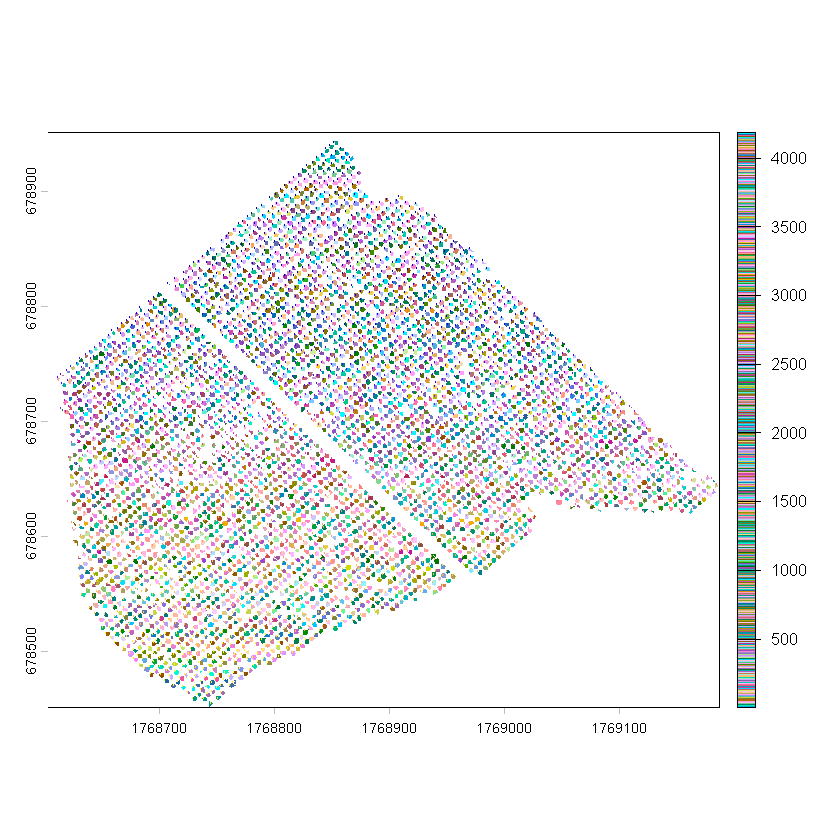

In [23]:
# Generate rasterized delineation
trees <- dalponte2016(chm = schm, treetops = ttops)() # Notice the parenthesis at the end
trees

plot(trees, col = col1)
plot(ttops, add = TRUE, cex = 0.1)

[1] "esrignss_speed"              "esrignss_direction"         
 [3] "esrisnsr_azimuth"            "esrignss_positionsourcetype"
 [5] "esrignss_receiver"           "esrignss_h_rms"             
 [7] "esrignss_v_rms"              "esrignss_latitude"          
 [9] "esrignss_longitude"          "esrignss_altitude"          
[11] "esrignss_fixdatetime"        "GlobalID"                   
[13] "Tree_Label"                  "GT_Height"                  
[15] "GT_DBH"                      "comon_name"                 
[17] "notes"                       "number_of_stems"            
[19] "esrignss_pdop"               "esrignss_hdop"              
[21] "esrignss_vdop"               "esrignss_fixtype"           
[23] "esrignss_correctionage"      "esrignss_stationid"         
[25] "esrignss_numsats"            "esrignss_avg_h_rms"         
[27] "esrignss_avg_v_rms"          "esrignss_avg_positions"     
[29] "esrignss_h_stddev"           "CreationDate"               
[31] "Creator"                     "EditDate"                   
[33] "Editor"